In [1]:
# Nếu Colab chưa có thư viện thì bỏ comment dòng dưới rồi chạy 1 lần.
%pip install folium geopy geopandas osmnx networkx scikit-learn

#**23.1**

Dùng thư viện Folium để tạo một bản đồ tương tác hiển thị vị trí của UEH, hoặc bệnh viện, trường học, hoặc một số địa điểm bạn tự chọn.
Người dùng phải có thể nhấn vào từng điểm để xem tên địa điểm, mô tả ngắn và hình minh họa nếu có. Bản đồ cần có popup trực quan và hỗ trợ phóng to, thu nhỏ.

In [2]:
import folium

center = [47.486269374376704, 19.0582984118707]

places = [
    ["Corvinus University of Budapest", 47.486269374376704, 19.0582984118707],
    ["Kinizsi Domitory", 47.484083259578384, 19.06214082864988],
    ["Fővám Square", 47.48726940033299, 19.057047364406372],
]

m1 = folium.Map(location=center, zoom_start=14)

for name, lat, lon in places:
    folium.Marker(
        [lat, lon],
        popup=name, #Hiện khi click
        tooltip=name #Hiện khi rê chuột
    ).add_to(m1)

m1

#**23.2**

Sử dụng GeoPy hoặc thư viện tương tự để chuyển đổi địa chỉ thực tế thành tọa độ địa lý.
Ví dụ có thể là địa chỉ nhà, chợ gần nhất hoặc một địa điểm cụ thể do bạn chọn. Sau đó, hãy trực quan hóa kết quả lên bản đồ và thể hiện được vị trí, khoảng cách và mối quan hệ không gian giữa các điểm.

In [3]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import pandas as pd
import time
import folium

geolocator = Nominatim(user_agent="gis_exercise")

addresses = [
    "Budapesti Corvinus Egyetem",
    "Buda Castle",
    "Fisherman's Bastion",
]

rows = []

for address in addresses:
    location = geolocator.geocode(address)
    latitude = location.latitude
    longitude = location.longitude
    distance = geodesic(center, (location.latitude, location.longitude)).km
    rows.append([
        address,
        latitude,
        longitude,
        distance])
    time.sleep(1) #Tạm dừng chương trình trong 1 giây
    #trước khi tiếp tục vòng lặp.

geo_df = pd.DataFrame(rows, columns=["address", "lat", "lon", "distance_km"])
geo_df

,address,lat,lon,distance_km
0,Budapesti Corvinus Egyetem,47.486280,19.058109,0.014318
1,Buda Castle,47.495991,19.039801,1.763889
2,Fisherman's Bastion,47.502305,19.034700,2.518065


In [4]:
m2 = folium.Map(location=center, zoom_start=12)
#location là center với lon và lat đã khai báo trước đó

folium.Marker(center, popup="Điểm trung tâm", tooltip="Center").add_to(m2)

for row in geo_df.itertuples():
    folium.Marker(
        [row.lat, row.lon],
        popup=f"Khoảng cách từ {row.address} đến Corvinus: {row.distance_km:.2f} km từ vị trí trung tâm",
        tooltip=row.address
    ).add_to(m2)

m2

#**23.3**

Tạo một bản đồ nhiệt (heatmap) thể hiện mật độ phân bố của một hiện tượng như:

khách hàng,
hóa đơn bán hàng,
dân cư,
điểm giao hàng.

Bản đồ phải giúp người xem nhận biết được khu vực có mật độ cao và giải thích được ý nghĩa quản trị của các “vùng nóng”.

In [5]:
import numpy as np
from folium.plugins import HeatMap
import folium
import pandas as pd

np.random.seed(100)

#Địa chỉ random
latitudes = np.random.normal(center[0],0.01,200)
longitudes = np.random.normal(center[1],0.01,200)
orders = list(zip(latitudes, longitudes))
#Hoặc dùng dataframe


m3 = folium.Map(location=center, zoom_start=13)
HeatMap(orders).add_to(m3)

# Nếu muốn học sâu hơn:
# HeatMap([[lat, lon, weight], ...])  # thêm trọng số cho từng điểm

m3

#**23.4**

Dùng GeoPandas để đọc dữ liệu ranh giới hành chính như tỉnh/thành, quận/huyện hoặc phường/xã, rồi kết hợp với một chỉ tiêu kinh tế - xã hội như:

dân số,
doanh thu,
số hộ kinh doanh,
thu nhập bình quân.

Kết quả cần được thể hiện bằng bản đồ choropleth để phản ánh sự khác biệt không gian giữa các khu vực.

In [6]:
import geopandas as gpd
from shapely.geometry import box
import folium

areas = gpd.GeoDataFrame(
    {
        "zone": ["A", "B", "C", "D"],
        "sales": [120, 80, 150, 60]
    },
    geometry=[
      box(19.05629, 47.486269, 19.05829, 47.488269),  # A: Tây Bắc
      box(19.05829, 47.486269, 19.06029, 47.488269),  # B: Đông Bắc
      box(19.05629, 47.484269, 19.05829, 47.486269),  # C: Tây Nam
      box(19.05829, 47.484269, 19.06029, 47.486269),  # D: Đông Nam
    ],
    crs="EPSG:4326"
)

m4 = folium.Map(location=center, zoom_start=14)

folium.Choropleth(
    geo_data=areas, #Phân hình học: cột geometry
    data=areas, #Bảng dữ liệu chứa zone, sales
    columns=["zone", "sales"],
    key_on="feature.properties.zone",
    fill_color="YlOrRd"
).add_to(m4)

folium.GeoJson(
    areas, #Vẽ vùng polygame từ areas lên bản đồ
    tooltip=folium.GeoJsonTooltip(fields=["zone", "sales"])
    #Tạo ô hiển thị giá trị của 2 cột zone và sales
).add_to(m4)

m4

#**23.5**

Xây dựng mô hình vùng phục vụ (service area) cho một trung tâm phân phối hoặc cửa hàng.
Hãy sử dụng dữ liệu tọa độ để vẽ các vòng bán kính phục vụ khác nhau như 3 km, 5 km, 10 km, từ đó phân tích phạm vi hoạt động tối ưu và đánh giá khả năng tiếp cận khách hàng.

In [7]:
import geopandas as gpd
from shapely.geometry import Point
import folium

# Tạo điểm trung tâm
center_point = gpd.GeoDataFrame(
    geometry=[Point(center[1], center[0])],
    #Điểm trung tâm được biểu diễn qua Point(lon, lat)
    #Point là đối tượng hình học (Point, Polygon, LineString,...)
    crs="EPSG:4326"
).to_crs(3857)


# Tạo buffer 3km, 5km, 10km
distances = [10, 5, 3]
colors = {3: "green", 5: "orange", 10: "red"}

m5 = folium.Map(location=center, zoom_start=12)

for km in distances:
    buf = center_point.buffer(km * 1000).to_crs(4326).geometry.iloc[0] #lấy hàng đầu tiên
    #Tạo buffer quanh điểm point đã khai báo trước đó
    folium.GeoJson(
        buf.__geo_interface__,
        #Chuyển hình học sang GeoJSON để Folium hiểu
        style_function=lambda x, color=colors[km]: {
            "fillColor": color,
            "color": color,
            "fillOpacity": 0.15
        },
        tooltip=f"Buffer {km} km"
    ).add_to(m5)

# Thêm marker trung tâm
folium.Marker(center, popup="Trung tâm").add_to(m5)

m5


#**23.6**

Dùng OSMnx để lấy dữ liệu mạng lưới giao thông đường bộ của một khu vực đô thị.
Hãy trực quan hóa mạng giao thông trên bản đồ và mô tả một số đặc trưng cơ bản như:

số lượng nút giao,
chiều dài đường,
mật độ mạng lưới.

Từ đó, đánh giá xem mạng giao thông đó có phù hợp cho các ứng dụng AI đô thị thông minh hay không.

Số nút giao: 817
Số đoạn đường: 1538
Tổng chiều dài đường (km): 148.35


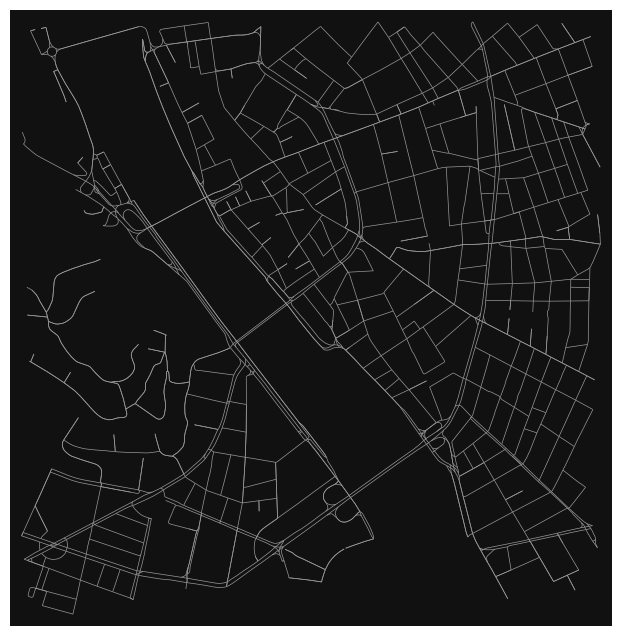

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [8]:
import osmnx as ox

G = ox.graph_from_point(center, dist=1500, network_type="drive")

nodes, edges = ox.graph_to_gdfs(G)

print("Số nút giao:", len(nodes))
print("Số đoạn đường:", len(edges))
print("Tổng chiều dài đường (km):", round(edges["length"].sum() / 1000, 2))
#Ban đầu là mét -> chuyển sang km / 1000

ox.plot_graph(G, node_size=0, edge_linewidth=0.5)


#**23.7**

Sử dụng NetworkX để xây dựng chương trình tìm đường đi ngắn nhất giữa hai địa điểm bất kỳ trong khu vực nghiên cứu.
So sánh kết quả của ít nhất hai thuật toán khác nhau, chẳng hạn như Dijkstra và A*. Đồng thời:

hiển thị tuyến đường trên bản đồ,
phân tích ưu điểm và nhược điểm của từng phương pháp.

Độ dài Dijkstra (km): 0.51
Độ dài A* (km): 0.51


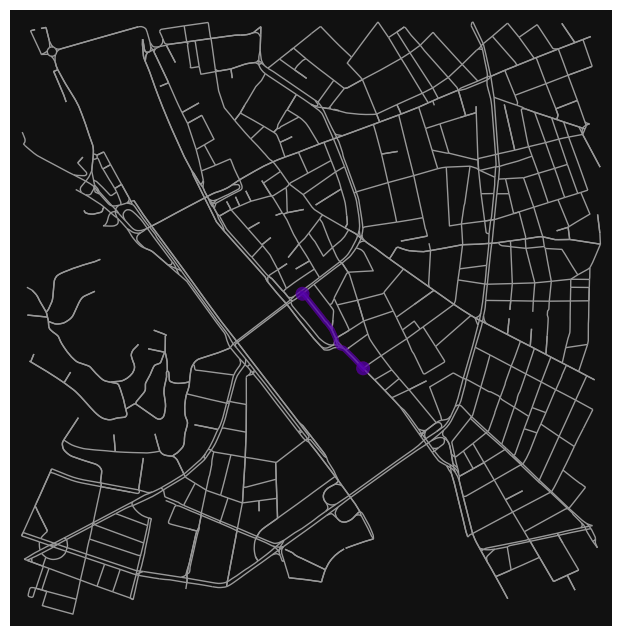

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [9]:
import networkx as nx
import osmnx as ox

origin = (47.486269374376704, 19.0582984118707)
#Corvinus University of Budapest
destination = (47.484083259578384, 19.06214082864988)
#Kinizsi Dorimotry

origin_node = ox.distance.nearest_nodes(G, X=origin[1], Y=origin[0])
destination_node = ox.distance.nearest_nodes(G, X=destination[1], Y=destination[0])

route_dijkstra = nx.shortest_path(G, origin_node, destination_node, weight="length")

route_astar = nx.astar_path(
    G,
    origin_node,
    destination_node,
    heuristic=lambda a, b: ((G.nodes[a]["x"] - G.nodes[b]["x"])**2 + (G.nodes[a]["y"] - G.nodes[b]["y"])**2) ** 0.5,
    weight="length"
)

print("Độ dài Dijkstra (km):", round(nx.path_weight(G, route_dijkstra, "length") / 1000, 2))
print("Độ dài A* (km):", round(nx.path_weight(G, route_astar, "length") / 1000, 2))

ox.plot_graph_routes(
    G,
    [route_dijkstra, route_astar],
    route_colors=["red", "blue"],
    node_size=0,
    route_linewidth=4
)

#**23.8**

Mô phỏng một hệ thống gọi xe công nghệ đơn giản.
Trong đó:

vị trí khách hàng và xe được biểu diễn bằng tọa độ trên bản đồ,
áp dụng một phương pháp AI hoặc heuristic để gán xe phù hợp nhất cho từng khách hàng dựa trên khoảng cách hoặc thời gian di chuyển.

Toàn bộ quá trình ghép xe với khách cần được trực quan hóa trên bản đồ.

In [10]:
from geopy.distance import geodesic
import pandas as pd
import folium

# Dữ liệu xe và khách
cars = pd.DataFrame({
    "driver": ["Xe 1", "Xe 2", "Xe 3"],
    "lat": [47.4868, 47.4882, 47.48419680578445],
    "lon": [19.0572, 19.0601, 19.062194469442193]
})

customers = pd.DataFrame({
    "customer": ["Khách A", "Khách B", "Khách C"],
    "lat": [47.4871, 47.4856, 47.483521740035435],
    "lon": [19.0589, 19.0594, 19.06077206483496]
})

# Ghép xe với khách (greedy)
matches = []
for c in customers.itertuples():
    cars["distance_km"] = cars.apply(
        lambda r: geodesic((c.lat, c.lon), (r.lat, r.lon)).km, axis=1
    )
    best = cars.loc[cars["distance_km"].idxmin()]
    matches.append([c.customer, best.driver, best.distance_km, c.lat, c.lon, best.lat, best.lon])
    cars = cars[cars.driver != best.driver]

matches = pd.DataFrame(matches, columns=["customer","driver","distance_km","c_lat","c_lon","d_lat","d_lon"])
print(matches)
# Vẽ bản đồ
center = [47.4868, 19.0572]  # tuỳ chọn điểm trung tâm
m8 = folium.Map(location=center, zoom_start=16)

# Marker xe (xanh) và khách (đỏ)
for _, r in matches.iterrows():
    folium.Marker([r.d_lat, r.d_lon], popup=r.driver, icon=folium.Icon(color="blue")).add_to(m8)
    folium.Marker([r.c_lat, r.c_lon], popup=r.customer, icon=folium.Icon(color="red")).add_to(m8)
    folium.PolyLine([(r.d_lat, r.d_lon), (r.c_lat, r.c_lon)],
                    color="green", weight=3,
                    popup=f"{r.driver} -> {r.customer} ({r.distance_km:.2f} km)").add_to(m8)

m8


  customer driver  distance_km      c_lat      c_lon      d_lat      d_lon
0  Khách A   Xe 1     0.132386  47.487100  19.058900  47.486800  19.057200
1  Khách B   Xe 3     0.262094  47.485600  19.059400  47.484197  19.062194
2  Khách C   Xe 2     0.522591  47.483522  19.060772  47.488200  19.060100


#**23.9**

Thực hiện phân cụm dữ liệu vị trí của khách hàng hoặc đơn hàng.
Dựa trên kết quả phân cụm, hãy đề xuất vị trí đặt trạm xe, kho hàng hoặc điểm trung chuyển tối ưu.
Kết quả phải được trình bày trên bản đồ và có phần giải thích logic quản trị đi kèm.


In [11]:
from sklearn.cluster import KMeans
import folium
import pandas as pd

# Đảm bảo orders là DataFrame với cột lat, lon
orders = pd.DataFrame(orders, columns=["lat", "lon"])

# Gom cụm KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
orders["cluster"] = kmeans.fit_predict(orders[["lat", "lon"]])

# Tâm cụm
centers = kmeans.cluster_centers_
colors = ["red", "blue", "green"]

# Vẽ bản đồ
m9 = folium.Map(location=center, zoom_start=13)

# Vẽ điểm đơn hàng
for _, r in orders.iterrows():
    # Chuyển đổi r.cluster sang int để dùng làm chỉ mục
    folium.CircleMarker([r.lat, r.lon], radius=4, color=colors[int(r.cluster)], fill=True).add_to(m9)

# Vẽ tâm cụm
for i, (lat, lon) in enumerate(centers):
    folium.Marker([lat, lon], popup=f"Tâm cụm {i}", icon=folium.Icon(color="black")).add_to(m9)

m9

#**23.10**

Xây dựng bản đồ phân tích nguy cơ tắc nghẽn giao thông dựa trên dữ liệu mô phỏng hoặc dữ liệu mở.
Áp dụng một mô hình AI đơn giản hoặc logic rule-based để phân loại những tuyến đường/khu vực có nguy cơ ùn tắc.
Bản đồ cần thể hiện rõ:

vùng rủi ro,
gợi ý tuyến thay thế nếu có.


In [12]:
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import folium

# center phải là (lat, lon)
center = (47.486269374376704, 19.0582984118707)

# Chuyển sang hệ mét để tính khoảng cách quanh CUB cho đúng
p = gpd.GeoSeries([Point(center[1], center[0])], crs="EPSG:4326").to_crs(epsg=3857).iloc[0]
edges2 = edges.to_crs(epsg=3857).copy()
edges2["dist_m"] = edges2.geometry.distance(p)

# Lấy 4 đoạn đường gần CUB nhất trong phạm vi 500m
sample = edges2[edges2["dist_m"] < 500].sort_values("length", ascending=False).head(4).copy()

# Gán dữ liệu mô phỏng cho bài toán nguy cơ tắc nghẽn
sample["speed_kmh"] = [10, 18, 35, 20]
sample["volume"] = [95, 82, 40, 70]

sample["risk"] = np.where(
    (sample["speed_kmh"] < 15) & (sample["volume"] > 80), "Cao",
    np.where(sample["speed_kmh"] < 25, "Trung bình", "Thấp")
)

sample = sample.to_crs(epsg=4326)

colors = {"Cao": "red", "Trung bình": "orange", "Thấp": "green"}

m10 = folium.Map(location=center, zoom_start=17)
folium.Marker(center, popup="CUB").add_to(m10)

for row in sample.itertuples():
    coords = [(y, x) for x, y in row.geometry.coords]
    folium.PolyLine(
        coords,
        color=colors[row.risk],
        weight=7,
        popup=f"Nguy cơ: {row.risk} | Tốc độ: {row.speed_kmh} km/h | Lưu lượng: {row.volume}"
    ).add_to(m10)

m10

#**23.11**

Ứng dụng một mô hình để dự đoán nhu cầu dịch vụ theo khu vực và thời gian, ví dụ như:

nhu cầu xe công nghệ,
nhu cầu giao hàng.

Hãy sử dụng một mô hình học máy phù hợp để dự báo từ dữ liệu lịch sử, rồi thể hiện sự khác biệt về nhu cầu giữa các khu vực trên bản đồ hoặc theo thời điểm.

In [13]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import folium

np.random.seed(42)

history = []
base_zone = {"A": 80, "B": 60, "C": 100, "D": 50}
base_hour = {8: 20, 12: 35, 18: 55, 20: 40}

for day in range(1, 8):
    for zone in ["A", "B", "C", "D"]:
        for hour in [8, 12, 18, 20]:
            demand = base_zone[zone] + base_hour[hour] + np.random.randint(-5, 6)
            history.append([day, zone, hour, demand])

history = pd.DataFrame(history, columns=["day", "zone", "hour", "demand"])

X = pd.get_dummies(history[["zone", "hour"]], drop_first=True)
y = history["demand"]

model = LinearRegression()
model.fit(X, y)

future = pd.DataFrame({"zone": ["A", "B", "C", "D"], "hour": [19, 19, 19, 19]})
future_X = pd.get_dummies(future)
future_X = future_X.reindex(columns=X.columns, fill_value=0)

areas["pred_demand"] = model.predict(future_X).round(0)
areas[["zone", "pred_demand"]]

,zone,pred_demand
0,A,127.0
1,B,108.0
2,C,148.0
3,D,97.0


In [14]:
m11 = folium.Map(location=center, zoom_start=14)

folium.Choropleth(
    geo_data=areas,
    data=areas,
    columns=["zone", "pred_demand"],
    key_on="feature.properties.zone",
    fill_color="PuBu"
).add_to(m11)

folium.GeoJson(
    areas,
    tooltip=folium.GeoJsonTooltip(fields=["zone", "pred_demand"])
).add_to(m11)

m11

#**23.12**

Mô phỏng một bài toán tối ưu hóa tuyến giao hàng/giao thông với nhiều kho và nhiều khách hàng.
Sử dụng một heuristic hoặc thuật toán AI để tạo ra tuyến giao hàng tối ưu sao cho:

tổng quãng đường nhỏ nhất, hoặc
tổng thời gian di chuyển nhỏ nhất.

Kết quả phải được thể hiện trên bản đồ và có đánh giá về hiệu quả của giải pháp.

In [15]:
from geopy.distance import geodesic
import pandas as pd
import folium

center = [47.486269374376704, 19.0582984118707]

# 1. Nhiều kho
depots = pd.DataFrame({
    "depot": ["Kho 1", "Kho 2"],
    "lat": [47.48409773171504 , 47.4874],
    "lon": [19.06201207939168, 19.0608]
})

# 2. Nhiều khách hàng quanh CUB
customers = pd.DataFrame({
    "customer": ["C1", "C2", "C3", "C4", "C5", "C6"],
    "lat": [47.4826026056095, 47.4864, 47.4870, 47.482427525120045, 47.477887243319216, 47.4878],
    "lon": [19.066482422052598, 19.0587, 19.0595, 19.067273149982327, 19.060376013863, 19.0612]
})

# 3. Gán mỗi khách cho kho gần nhất
assigned = []
for c in customers.itertuples():
    depots["dist"] = depots.apply(
        lambda d: geodesic((c.lat, c.lon), (d.lat, d.lon)).km,
        axis=1
    )
    best = depots.sort_values("dist").iloc[0]
    assigned.append(best["depot"])

customers["depot"] = assigned

# 4. Tạo tuyến cho từng kho bằng heuristic gần nhất
routes = {}
total_distance = 0

for d in depots.itertuples():
    group = customers[customers["depot"] == d.depot][["customer", "lat", "lon"]].to_dict("records")

    current = (d.lat, d.lon)
    route = [current]
    distance = 0

    while group:
        next_stop = min(group, key=lambda x: geodesic(current, (x["lat"], x["lon"])).km)
        next_point = (next_stop["lat"], next_stop["lon"])
        distance += geodesic(current, next_point).km
        route.append(next_point)
        current = next_point
        group.remove(next_stop)

    distance += geodesic(current, (d.lat, d.lon)).km
    route.append((d.lat, d.lon))

    routes[d.depot] = route
    total_distance += distance

print("Tổng quãng đường ước lượng (km):", round(total_distance, 2))

# 5. Vẽ bản đồ
m12 = folium.Map(location=center, zoom_start=17)
colors = {"Kho 1": "blue", "Kho 2": "red"}

for d in depots.itertuples():
    folium.Marker(
        [d.lat, d.lon],
        popup=d.depot,
        icon=folium.Icon(color="black")
    ).add_to(m12)

for c in customers.itertuples():
    folium.Marker(
        [c.lat, c.lon],
        popup=f"{c.customer} - {c.depot}"
    ).add_to(m12)

for depot_name, route in routes.items():
    folium.PolyLine(
        route,
        color=colors[depot_name],
        weight=4,
        popup=depot_name
    ).add_to(m12)

m12

Tổng quãng đường ước lượng (km): 2.36


#**23.13**

Thiết kế một dashboard bản đồ có khả năng kết hợp nhiều lớp dữ liệu khác nhau như:

tắc nghẽn giao thông,
nhu cầu đơn hàng,
vị trí xe,
vị trí kho hàng,
đơn hàng.

Dashboard cần hỗ trợ tương tác cơ bản và phục vụ cho mục đích báo cáo điều hành hoặc ra quyết định chiến lược.



In [16]:
from folium.plugins import HeatMap
import folium

m13 = folium.Map(location=center, zoom_start=17)

# 1. Mật độ đơn hàng - lấy từ bài 23.3
layer_orders = folium.FeatureGroup(name="Mật độ đơn hàng")
HeatMap(orders[["lat", "lon"]].values.tolist(), radius=18).add_to(layer_orders)
layer_orders.add_to(m13)

# 2. Kho - lấy từ bài 23.12
layer_depots = folium.FeatureGroup(name="Kho")
for d in depots.itertuples():
    folium.Marker(
        [d.lat, d.lon],
        popup=d.depot,
        icon=folium.Icon(color="black")
    ).add_to(layer_depots)
layer_depots.add_to(m13)

# 3. Xe - lấy từ bài 23.8
layer_cars = folium.FeatureGroup(name="Xe")
for row in cars.itertuples():
    folium.Marker(
        [row.lat, row.lon],
        popup=row.driver,
        icon=folium.Icon(color="blue")
    ).add_to(layer_cars)
layer_cars.add_to(m13)

# 4. Tuyến giao hàng - lấy từ bài 23.12
layer_routes = folium.FeatureGroup(name="Tuyến giao hàng")
route_colors = {"Kho 1": "blue", "Kho 2": "red"}
for depot_name, route in routes.items():
    folium.PolyLine(
        route,
        color=route_colors[depot_name],
        weight=4,
        popup=depot_name
    ).add_to(layer_routes)
layer_routes.add_to(m13)

# 5. Nguy cơ tắc nghẽn - lấy từ bài 23.10
layer_risk = folium.FeatureGroup(name="Nguy cơ tắc nghẽn")
risk_colors = {"Cao": "red", "Trung bình": "orange", "Thấp": "green"}

for row in sample.itertuples():
    coords = [(y, x) for x, y in row.geometry.coords]
    folium.PolyLine(
        coords,
        color=risk_colors[row.risk],
        weight=6,
        popup=f"Nguy cơ {row.risk}"
    ).add_to(layer_risk)
layer_risk.add_to(m13)

folium.LayerControl().add_to(m13)

m13

#**23.14**

Xây dựng một mô phỏng hệ thống điều phối xe theo thời gian.
Trong đó, xe sẽ di chuyển qua mạng đường, còn trạng thái của hệ thống sẽ được cập nhật liên tục.
Quá trình mô phỏng cần được trực quan hóa trên bản đồ theo từng bước thời gian.


In [17]:
from folium.plugins import TimestampedGeoJson
import folium

center = [47.486269374376704, 19.0582984118707]

times = [
    "2026-01-01T08:00:00",
    "2026-01-01T08:15:00",
    "2026-01-01T08:30:00",
    "2026-01-01T08:45:00",
]

vehicle_paths = {
    "Xe 1": [
        (47.4854, 19.0568),
        (47.4859, 19.0576),
        (47.4865, 19.0585),
        (47.4871, 19.0594),
    ],
    "Xe 2": [
        (47.4875, 19.0608),
        (47.4870, 19.0600),
        (47.4864, 19.0591),
        (47.4858, 19.0582),
    ],
}

# Tạo danh sách features
features = [
    {
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [lon, lat]},
        "properties": {
            "times": [t],
            "popup": vehicle,
            "icon": "circle",
            "iconstyle": {"fillColor": "blue", "fillOpacity": 0.8, "radius": 6}
        }
    }
    for vehicle, path in vehicle_paths.items()
    for t, (lat, lon) in zip(times, path)
]

# Vẽ bản đồ
m14 = folium.Map(location=center, zoom_start=17)
folium.Marker(center, popup="CUB / Center").add_to(m14)

TimestampedGeoJson(
    {"type": "FeatureCollection", "features": features},
    period="PT15M", auto_play=False, add_last_point=True
).add_to(m14)

m14


#**23.15**

Đề xuất một ứng dụng AI dựa trên bản đồ liên quan đến một lĩnh vực bạn quan tâm, chẳng hạn như:

quản lý đô thị,
vận tải,
logistics,
kinh doanh.

Bài làm cần nêu rõ:

ý tưởng ứng dụng,
bài toán cần giải quyết,
dữ liệu cần dùng,
phương pháp AI,
cách trực quan hóa trên bản đồ,
giá trị thực tiễn của ứng dụng.

In [18]:
import pandas as pd

proposal = pd.DataFrame({
    "Thành phần": ["Bài toán", "Dữ liệu", "Mô hình", "Đầu ra bản đồ", "Giá trị"],
    "Nội dung": [
        "Dự báo nhu cầu giao hàng theo khu vực",
        "Đơn hàng, thời gian, vị trí, mạng đường",
        "Forecasting + Clustering + Routing",
        "Heatmap + cụm khách hàng + tuyến giao hàng",
        "Giảm chi phí và tăng tốc độ giao"
    ]
})

proposal

,Thành phần,Nội dung
0,Bài toán,Dự báo nhu cầu giao hàng theo khu vực
1,Dữ liệu,"Đơn hàng, thời gian, vị trí, mạng đường"
2,Mô hình,Forecasting + Clustering + Routing
3,Đầu ra bản đồ,Heatmap + cụm khách hàng + tuyến giao hàng
4,Giá trị,Giảm chi phí và tăng tốc độ giao
